In [349]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [350]:
df = pd.read_csv('menzili_properties.csv')

In [351]:
df.head()

,price,property_type,bedrooms,bathrooms,total_rooms,living_area,land_area,construction_year,neighborhood,city,...,interphone,terrace,electric_heating,elevator,alarm_system,internet_access,sea_view,furnished,central_heating,kitchen_equipped
0,1250000.0,Appartement,3,NaN,4,178.0,178.0,NaN,La Marsa,Tunis,...,1,1,1,1,1,1,1,0,1,1
1,360000.0,Appartement,3,NaN,4,110.0,110.0,NaN,La Marsa,Tunis,...,1,1,1,1,1,1,1,1,1,1
2,320000.0,Appartement,1,1,NaN,53.0,0.0,NaN,La Marsa,Tunis,...,1,1,1,1,1,1,1,1,1,1
3,422000.0,Appartement,2,2,3,125.0,125.0,2022.0,La Soukra,Ariana,...,0,0,0,0,1,0,1,1,0,0
4,245000.0,Appartement,1,1,2,74.0,0.0,2024.0,Mrezga,Nabeul,...,0,0,1,1,0,0,1,1,0,0


In [352]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14349 entries, 0 to 14348
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               14349 non-null  float64
 1   property_type       14349 non-null  object 
 2   bedrooms            11240 non-null  object 
 3   bathrooms           10274 non-null  object 
 4   total_rooms         9103 non-null   object 
 5   living_area         14349 non-null  float64
 6   land_area           14349 non-null  float64
 7   construction_year   3764 non-null   float64
 8   neighborhood        14341 non-null  object 
 9   city                14341 non-null  object 
 10  climatisation       14349 non-null  int64  
 11  parabole_tv         14349 non-null  int64  
 12  pool                14349 non-null  int64  
 13  handicapped_access  14349 non-null  int64  
 14  parking             14349 non-null  int64  
 15  garage              14349 non-null  int64  
 16  gard

In [353]:
df['price'].describe()

count    1.434900e+04
mean     6.970098e+10
std      8.348130e+12
min      1.000000e+00
25%      1.250000e+05
50%      2.650000e+05
75%      5.500000e+05
max      1.000000e+15
Name: price, dtype: float64

In [354]:
df = df[df['price'] >= 80000]

In [355]:
df['price'].describe()

count    1.154100e+04
mean     8.665968e+10
std      9.308469e+12
min      8.000000e+04
25%      2.020000e+05
50%      3.400000e+05
75%      6.500000e+05
max      1.000000e+15
Name: price, dtype: float64

In [356]:
df['property_type'].unique()

array(['Appartement', 'Maison'], dtype=object)

For your house price prediction models (Linear Regression, XGBoost, and Random Forest), the best encoding approach for the 'property_type' column depends on your specific dataset and models.

Since you only have two categories ('Appartement' and 'Maison'), both binary encoding and one-hot encoding will give mathematically equivalent results. However, binary encoding is slightly more efficient and interpretable in this case.

In [357]:
# Fix the SettingWithCopyWarning by using .loc
df.loc[:, 'property_type'] = df['property_type'].map({'Appartement': 0, 'Maison': 1})

# Verify the conversion
df['property_type'].unique()

array([0, 1], dtype=object)

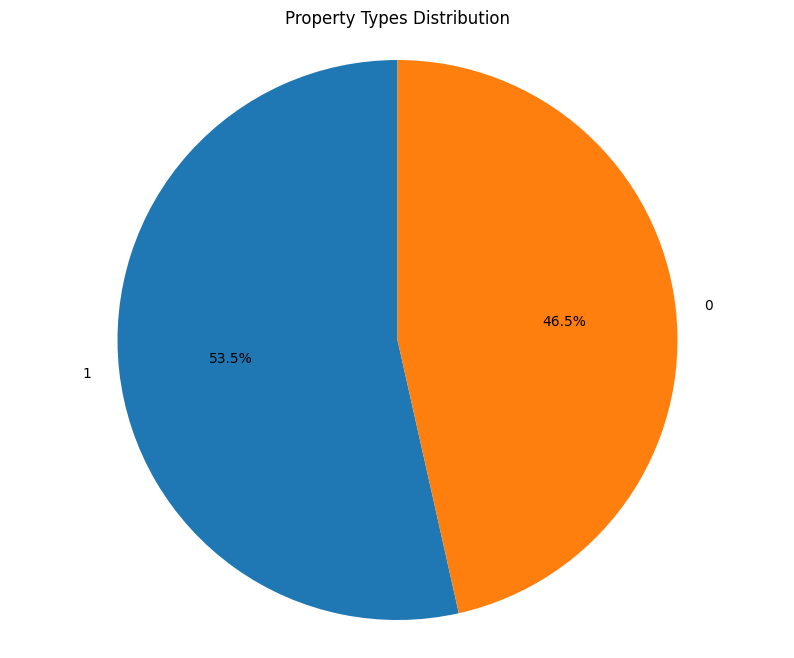


Property Type Counts:
property_type
1    6176
0    5365
Name: count, dtype: int64


In [358]:
# Create simple pie chart
plt.figure(figsize=(10, 8))
property_counts = df['property_type'].value_counts()

plt.pie(property_counts, 
        labels=property_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Property Types Distribution')
plt.axis('equal')
plt.show()

# Print counts
print("\nProperty Type Counts:")
print(property_counts)

In [359]:
df['bedrooms'].unique()

array(['3', '1', '2', '4', nan, '7', '5', '6', '10+', '9', '8'],
      dtype=object)

In [360]:
df = df.dropna(subset=['bedrooms'])

In [361]:
# Create a binary feature for "many bedrooms"
df.loc[:, 'many_bedrooms'] = (df['bedrooms'] == '10+').astype(int)

# Replace '10+' with 10 in the original column
df.loc[:, 'bedrooms'] = df['bedrooms'].replace('10+', '10')
df.loc[:, 'bedrooms'] = pd.to_numeric(df['bedrooms'])

# Verify the results
print(df[['bedrooms', 'many_bedrooms']].head(10))

  bedrooms  many_bedrooms
0        3              0
1        3              0
2        1              0
3        2              0
4        1              0
5        3              0
6        3              0
7        2              0
8        2              0
9        4              0


In [362]:
# Convert bedrooms to numeric type
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')

# Now get descriptive statistics
bedroom_stats = df['bedrooms'].describe()
print(bedroom_stats)

# Get additional statistics
print(f"\nMean number of bedrooms: {df['bedrooms'].mean():.2f}")
print(f"Median number of bedrooms: {df['bedrooms'].median()}")
print(f"Mode number of bedrooms: {df['bedrooms'].mode()[0]}")

count    9163.000000
mean        3.294009
std         1.730977
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedrooms, dtype: float64

Mean number of bedrooms: 3.29
Median number of bedrooms: 3.0
Mode number of bedrooms: 3


In [363]:
count_many_bedrooms = df['many_bedrooms'].sum()

print(f"Number of properties with 10+ bedrooms: {count_many_bedrooms}")

percentage = (count_many_bedrooms / len(df)) * 100
print(f"Percentage of properties with 10+ bedrooms: {percentage:.2f}%")

Number of properties with 10+ bedrooms: 135
Percentage of properties with 10+ bedrooms: 1.47%


In [364]:
# Get descriptive statistics for the bedrooms column
bedroom_stats = df['bedrooms'].describe()
print(bedroom_stats)

count    9163.000000
mean        3.294009
std         1.730977
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedrooms, dtype: float64


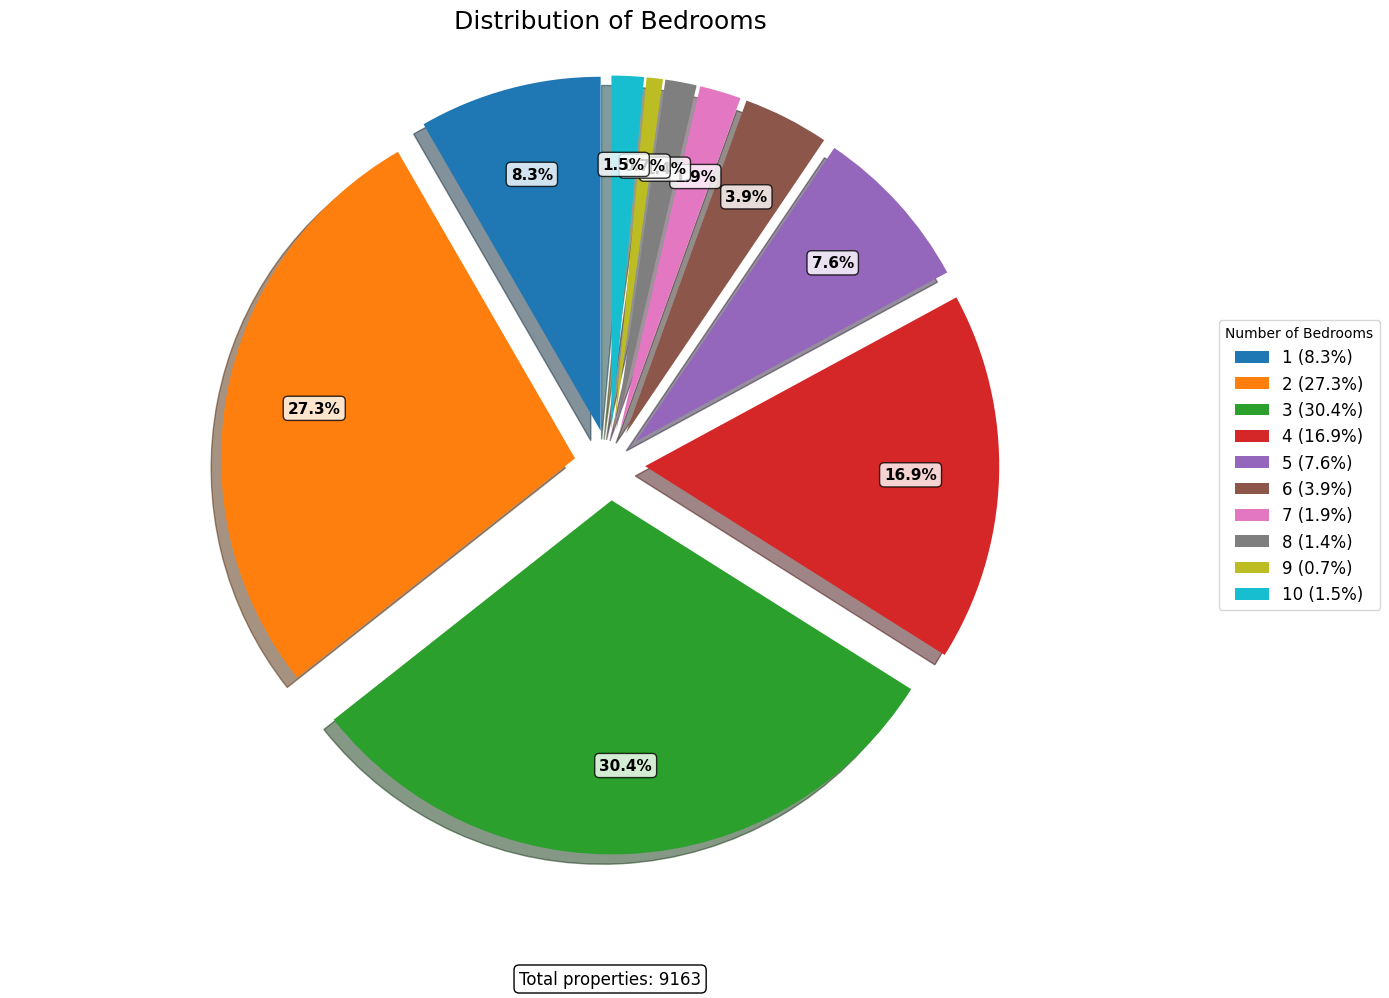

In [365]:

# Count the frequency of each bedroom value
bedroom_counts = df['bedrooms'].value_counts().sort_index()

# Calculate percentages for better labeling
percentages = (bedroom_counts / bedroom_counts.sum()) * 100
labels = [f'{idx} ({pct:.1f}%)' for idx, pct in zip(bedroom_counts.index, percentages)]

# Define a color palette with good contrast
colors = plt.cm.tab10(range(len(bedroom_counts)))

# Create a pie chart with enhanced visibility
plt.figure(figsize=(14, 10))

# Create the pie chart with percentage labels in the pie itself
wedges, texts, autotexts = plt.pie(bedroom_counts, labels=None, 
                       autopct='%1.1f%%',
                       startangle=90, shadow=True, 
                       explode=[0.1]*len(bedroom_counts),
                       colors=colors,
                       pctdistance=0.75)  # Position the percentages

# Enhance the appearance of percentage text on the pie
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')
    autotext.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

plt.title('Distribution of Bedrooms', fontsize=18)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Add a legend with percentages included in the labels
plt.legend(wedges, labels, title="Number of Bedrooms", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

# Add a text box with the total count
plt.annotate(f'Total properties: {bedroom_counts.sum()}', 
            xy=(0.5, -0.1), xycoords='axes fraction',
            ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

plt.tight_layout()
plt.show()

In [366]:
df['bathrooms'].unique()

array([nan, '1', '2', '4', '3', '6+', '5'], dtype=object)

In [367]:
# First, replace NaN values with '1' (most common value)
df['bathrooms'] = df['bathrooms'].fillna('1')

# Create a binary feature for "many bathrooms"
df['many_bathrooms'] = (df['bathrooms'] == '6+').astype(int)

# Replace '6+' with '6' in the original column
df['bathrooms'] = df['bathrooms'].replace('6+', '6')

# Convert bathrooms to numeric
df['bathrooms'] = pd.to_numeric(df['bathrooms'])

# Verify the conversion
print("Unique values in bathrooms column after conversion:")
print(df['bathrooms'].unique())
print("\nCount of properties with many bathrooms (6+):")
print(df['many_bathrooms'].sum())

Unique values in bathrooms column after conversion:
[1 2 4 3 6 5]

Count of properties with many bathrooms (6+):
96


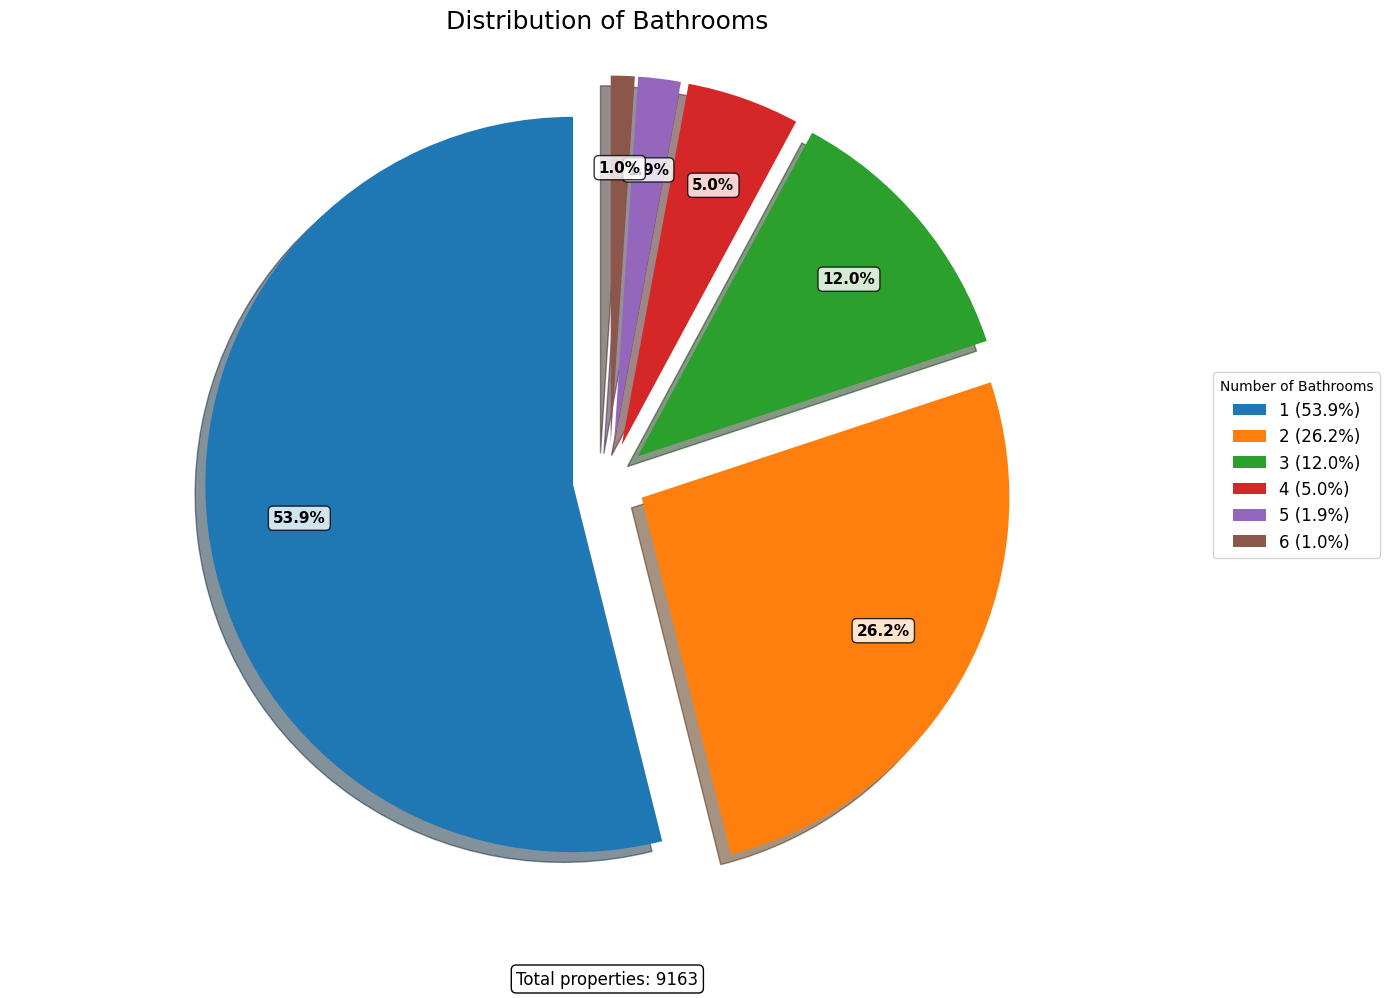

In [368]:
# Create a pie chart for bathroom distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each bathroom value
bathroom_counts = df['bathrooms'].value_counts().sort_index()

# Calculate percentages for better labeling
percentages = (bathroom_counts / bathroom_counts.sum()) * 100
labels = [f'{idx} ({pct:.1f}%)' for idx, pct in zip(bathroom_counts.index, percentages)]

# Define a color palette with good contrast
colors = plt.cm.tab10(range(len(bathroom_counts)))

# Create a pie chart with enhanced visibility
plt.figure(figsize=(14, 10))

# Create the pie chart with percentage labels in the pie itself
wedges, texts, autotexts = plt.pie(bathroom_counts, labels=None, 
                       autopct='%1.1f%%',
                       startangle=90, shadow=True, 
                       explode=[0.1]*len(bathroom_counts),
                       colors=colors,
                       pctdistance=0.75)  # Position the percentages

# Enhance the appearance of percentage text on the pie
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')
    autotext.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

plt.title('Distribution of Bathrooms', fontsize=18)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Add a legend with percentages included in the labels
plt.legend(wedges, labels, title="Number of Bathrooms", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

# Add a text box with the total count
plt.annotate(f'Total properties: {bathroom_counts.sum()}', 
            xy=(0.5, -0.1), xycoords='axes fraction',
            ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

plt.tight_layout()
plt.show()

In [369]:
# First, check how many null values we have
null_count = df['total_rooms'].isnull().sum()
print(f"Number of null values in total_rooms: {null_count}")

# Replace '10+' with '10' in the original column
df['total_rooms'] = df['total_rooms'].replace('10+', '10')

# Convert total_rooms to numeric
df['total_rooms'] = pd.to_numeric(df['total_rooms'], errors='coerce')

# Create a binary feature for "many rooms", initially all 0
df['many_total_rooms'] = 0

# Set many_total_rooms to 1 for existing values > 10
df.loc[df['total_rooms'] > 10, 'many_total_rooms'] = 1

# Cap values at 10
df.loc[df['total_rooms'] > 10, 'total_rooms'] = 10

# For null values, calculate as sum of other room types
null_mask = df['total_rooms'].isnull()
if null_mask.any():
    # Make sure all component columns are numeric
    for col in ['bedrooms', 'bathrooms']:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate the sum of component rooms
    room_sum = df.loc[null_mask, 'bedrooms'] + df.loc[null_mask, 'bathrooms'] + 2  # +2 for kitchen and salon
    
    # Set many_total_rooms to 1 where the sum > 10
    df.loc[null_mask & (room_sum > 10), 'many_total_rooms'] = 1
    
    # Cap the sum at 10 for total_rooms
    df.loc[null_mask, 'total_rooms'] = np.minimum(room_sum, 10)

# Verify the conversion
print("\nUnique values in total_rooms after conversion:")
print(df['total_rooms'].unique())
print(f"\nCount of properties with many rooms (>10): {df['many_total_rooms'].sum()}")

Number of null values in total_rooms: 1831

Unique values in total_rooms after conversion:
[ 4.  3.  2. 10.  5.  1.  6.  7.  8.  9.]

Count of properties with many rooms (>10): 160


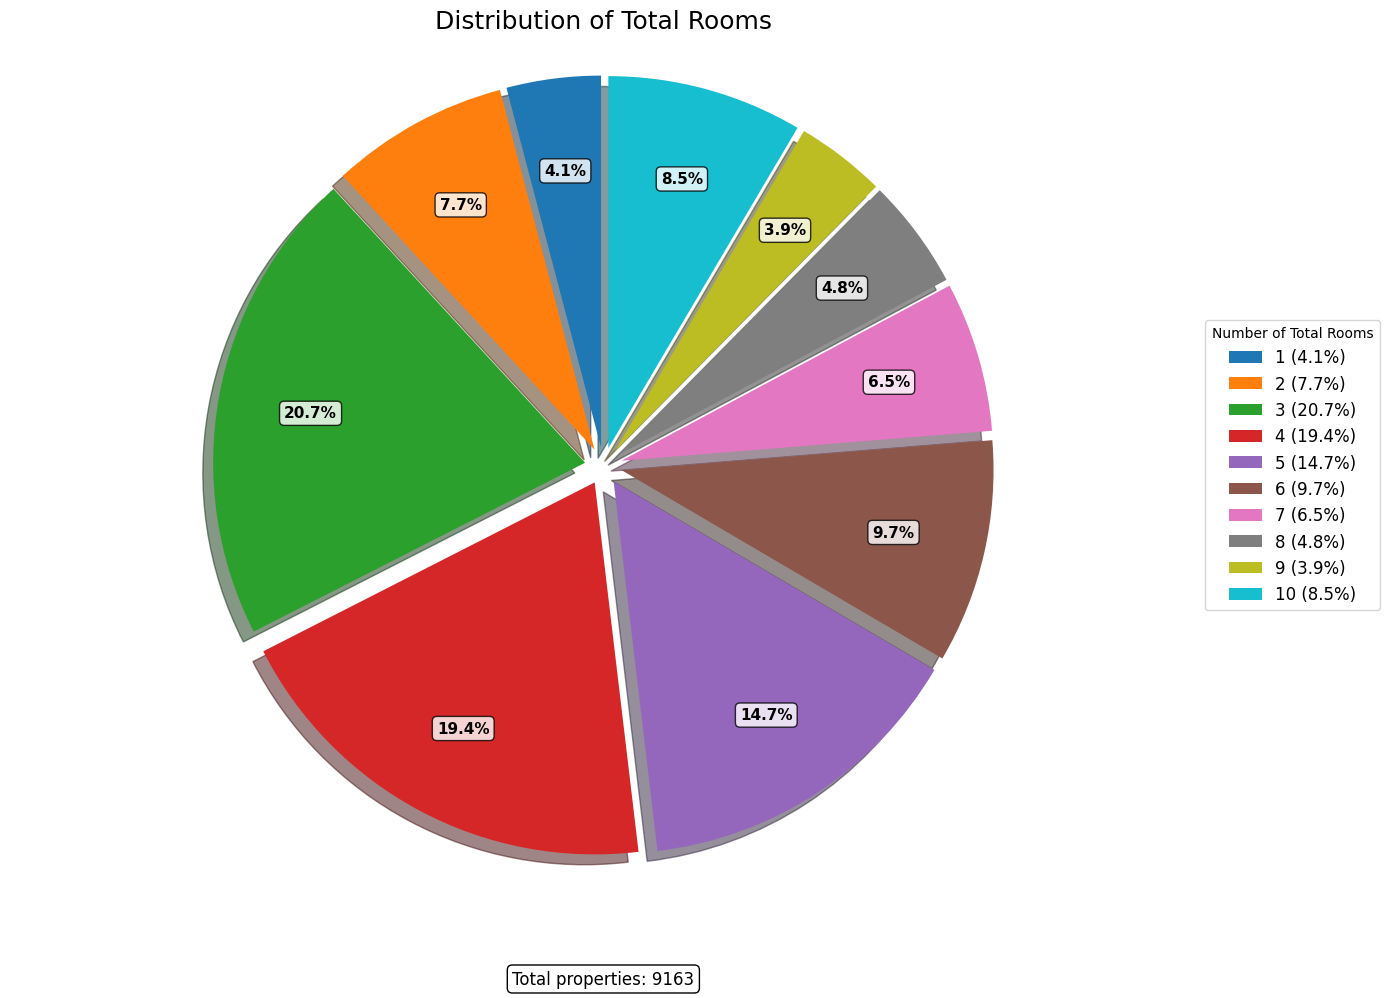

In [370]:
# Create a pie chart for total_rooms distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each total_rooms value
total_rooms_counts = df['total_rooms'].value_counts().sort_index()

# Calculate percentages for better labeling
percentages = (total_rooms_counts / total_rooms_counts.sum()) * 100
labels = [f'{int(idx)} ({pct:.1f}%)' for idx, pct in zip(total_rooms_counts.index, percentages)]

# Define a color palette with good contrast
colors = plt.cm.tab10(range(len(total_rooms_counts)))

# Create a pie chart with enhanced visibility
plt.figure(figsize=(14, 10))

# Create the pie chart with percentage labels
wedges, texts, autotexts = plt.pie(total_rooms_counts, labels=None, 
                       autopct='%1.1f%%',
                       startangle=90, shadow=True, 
                       explode=[0.05]*len(total_rooms_counts),
                       colors=colors,
                       pctdistance=0.75)  # Position the percentages

# Enhance the appearance of percentage text on the pie
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')
    autotext.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

plt.title('Distribution of Total Rooms', fontsize=18)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Add a legend with percentages included in the labels
plt.legend(wedges, labels, title="Number of Total Rooms", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

# Add a text box with the total count
plt.annotate(f'Total properties: {total_rooms_counts.sum()}', 
            xy=(0.5, -0.1), xycoords='axes fraction',
            ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

plt.tight_layout()
plt.show()

In [371]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9163 entries, 0 to 14348
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               9163 non-null   float64
 1   property_type       9163 non-null   object 
 2   bedrooms            9163 non-null   int64  
 3   bathrooms           9163 non-null   int64  
 4   total_rooms         9163 non-null   float64
 5   living_area         9163 non-null   float64
 6   land_area           9163 non-null   float64
 7   construction_year   2683 non-null   float64
 8   neighborhood        9160 non-null   object 
 9   city                9160 non-null   object 
 10  climatisation       9163 non-null   int64  
 11  parabole_tv         9163 non-null   int64  
 12  pool                9163 non-null   int64  
 13  handicapped_access  9163 non-null   int64  
 14  parking             9163 non-null   int64  
 15  garage              9163 non-null   int64  
 16  garden    

In [372]:
df['living_area'].describe()

count      9163.000000
mean        244.988889
std        2913.794773
min           0.000000
25%          91.000000
50%         140.000000
75%         248.500000
max      220000.000000
Name: living_area, dtype: float64

Step 1: First Handle Cases Where Only One is Zero


In [373]:
# Copy living_area to land_area when land is 0 but living has value
df.loc[(df['land_area'] == 0) & (df['living_area'] > 0), 'land_area'] = df['living_area']

# Copy land_area to living_area when living is 0 but land has value
df.loc[(df['living_area'] == 0) & (df['land_area'] > 0), 'living_area'] = df['land_area']

# For apartments (type 0), ensure land equals living where possible
df.loc[(df['property_type'] == 0) & (df['land_area'] == 0), 'land_area'] = df['living_area']

In [374]:
df['living_area'].describe()

count      9163.000000
mean        260.454621
std        2915.285914
min           0.000000
25%         100.000000
50%         145.000000
75%         255.000000
max      220000.000000
Name: living_area, dtype: float64

In [375]:
df['land_area'].describe()

count      9163.000000
mean        451.742368
std        6089.246030
min           0.000000
25%         100.000000
50%         156.000000
75%         345.000000
max      420000.000000
Name: land_area, dtype: float64

step 2 : Calculate Median Values


In [376]:
# Calculate median values for each property type
medians = df[(df['living_area'] > 0) | (df['land_area'] > 0)].groupby('property_type').agg({
    'living_area': 'median',
    'land_area': 'median'
}).to_dict('index')

# For apartments (type 0), set land median equal to living median if not available
if 0 in medians and np.isnan(medians[0]['land_area']):
    medians[0]['land_area'] = medians[0]['living_area']

In [377]:
# Create mask for properties where both are zero
both_zero = (df['living_area'] == 0) & (df['land_area'] == 0)

# Impute using property type medians
for prop_type in medians:
    mask = both_zero & (df['property_type'] == prop_type)
    df.loc[mask, 'living_area'] = medians[prop_type]['living_area']
    df.loc[mask, 'land_area'] = medians[prop_type]['land_area']

# Handle any remaining zeros (fallback to reasonable defaults)
still_zero = (df['living_area'] == 0) & (df['land_area'] == 0)
df.loc[still_zero & (df['property_type'] == 0), ['living_area', 'land_area']] = 80  # Default apartment size
df.loc[still_zero & (df['property_type'] == 1), ['living_area', 'land_area']] = (120, 180)  # Default house sizes

In [378]:
# Ensure apartments have land_area <= living_area
df.loc[(df['property_type'] == 0) & (df['land_area'] > df['living_area']), 'land_area'] = df['living_area']

# Ensure houses have land_area >= living_area
df.loc[(df['property_type'] == 1) & (df['land_area'] < df['living_area']), 'land_area'] = df['living_area'] * 1.2

In [379]:
print("Remaining zeros:", ((df['living_area'] == 0) | (df['land_area'] == 0)).sum())
print("\nSummary by property type:")

for prop_type, name in [(0, 'Apartment'), (1, 'House')]:
    subset = df[df['property_type'] == prop_type]
    print(f"\n{name} (Type {prop_type}):")
    print(f"Living Area: Mean={subset['living_area'].mean():.1f}, Median={subset['living_area'].median():.1f}")
    print(f"Land Area: Mean={subset['land_area'].mean():.1f}, Median={subset['land_area'].median():.1f}")
    print(f"Land/Living Ratio: {subset['land_area'].mean()/subset['living_area'].mean():.2f}")

Remaining zeros: 0

Summary by property type:

Apartment (Type 0):
Living Area: Mean=199.2, Median=108.0
Land Area: Mean=195.4, Median=108.0
Land/Living Ratio: 0.98

House (Type 1):
Living Area: Mean=324.9, Median=240.0
Land Area: Mean=580.2, Median=347.0
Land/Living Ratio: 1.79


Why the Land/Living Ratio Helps (Plain English Explanation)
Imagine you're looking at two properties:

A cozy apartment (Type 0)

Living space: 80 m² (where you actually live)

Land area: 80 m² (same as living space, because it's just the apartment unit)

Ratio = 1.0 → Makes sense! No extra land.

A house with a garden (Type 1)

Living space: 100 m² (the house itself)

Land area: 250 m² (includes garden, driveway, etc.)

Ratio = 2.5 → Tells you the land is 2.5x bigger than the house.

Why This Matters for Pricing
✅ Houses with higher ratios (>>1) → Usually more valuable (bigger land = potential for gardens, pools, expansion).
✅ Apartments with ratio ≈1 → Normal (no extra land). If >>1, maybe a penthouse with a huge terrace?
❌ If a house has ratio <1 → Red flag! (Land smaller than the house? Probably bad data.)

How the Model Uses This
The model learns patterns like:

"Houses with ratio >2 sell for 20% more than those with ratio <1.5."

"Apartments with ratio >1.3 might have a terrace (premium feature)."

Without this ratio, the model just sees two numbers (land_area, living_area). The ratio connects them logically.

Real-World Example
You see two 100 m² houses priced differently:

House A: land_area = 100 m² → Ratio = 1.0 → "Wait, why is the land so small?"

House B: land_area = 300 m² → Ratio = 3.0 → "Ah, big garden! Higher price makes sense."

The ratio automatically flags these differences for the model.

When to Worry
⚠️ Apartments with ratio >1.5 → Maybe incorrect data (did someone mix up land_area with shared spaces?).
⚠️ Houses with ratio <1 → Impossible (land can’t be smaller than the building).

Simple Summary
Ratio ≈1 → Apartment (no extra land).

Ratio >>1 → House (extra land = more value).

Model loves it because it combines two numbers into one smart feature.

Ratio Statistics:
- Global mean: 1.37
- Apartments mean: 0.99
- Houses mean: 1.69


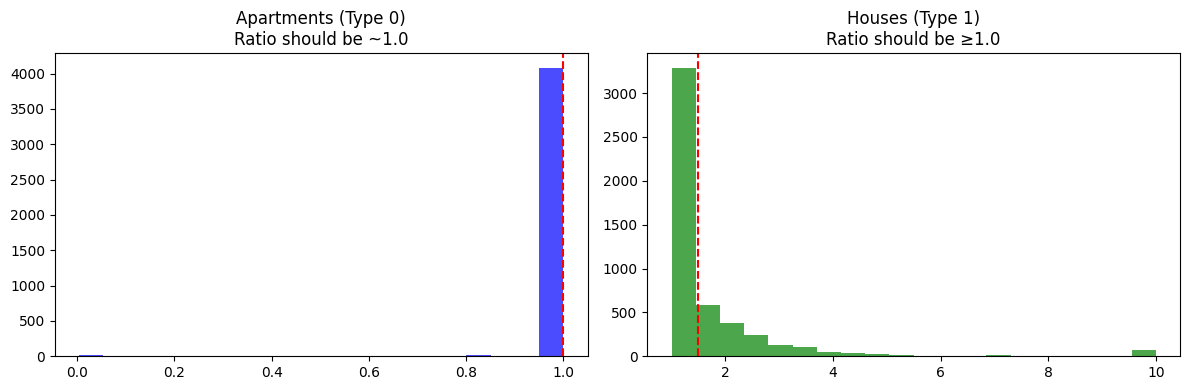

In [380]:

# ===================================================
# 1. CREATE THE BASIC RATIO COLUMN (with safeguards)
# ===================================================

# Calculate ratio (land_area / living_area)
df['land_living_ratio'] = np.where(
    df['living_area'] > 0,  # Only divide if living_area > 0
    df['land_area'] / df['living_area'],
    1.0  # Default ratio when living_area=0 (shouldn't happen after your cleaning)
)

# ===================================================
# 2. ADJUST RATIOS BASED ON PROPERTY TYPE
# ===================================================

# For APARTMENTS (type 0): Land should ≈ living area
apt_mask = (df['property_type'] == 0)
df.loc[apt_mask, 'land_living_ratio'] = df.loc[apt_mask, 'land_living_ratio'].clip(upper=1.2)  # Max 1.2x

# For HOUSES (type 1): Land should ≥ living area
house_mask = (df['property_type'] == 1)
df.loc[house_mask, 'land_living_ratio'] = df.loc[house_mask, 'land_living_ratio'].clip(lower=1.0)  # Min 1.0x

# Cap extreme values for all properties (e.g., land 50x bigger than house)
df['land_living_ratio'] = df['land_living_ratio'].clip(upper=10)  # Max 10x

# ===================================================
# 3. ADD A FLAG FOR SPECIAL CASES (Optional)
# ===================================================

# Flag where ratio was adjusted (helps debug model later)
df['ratio_was_adjusted'] = (
    (apt_mask & (df['land_living_ratio'] > 1.0)) | 
    (house_mask & (df['land_living_ratio'] < 1.5))
).astype(int)

# ===================================================
# 4. VALIDATE THE RESULTS
# ===================================================

print("Ratio Statistics:")
print(f"- Global mean: {df['land_living_ratio'].mean():.2f}")
print(f"- Apartments mean: {df[apt_mask]['land_living_ratio'].mean():.2f}")
print(f"- Houses mean: {df[house_mask]['land_living_ratio'].mean():.2f}")

# Visual check
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))

# Apartments
plt.subplot(1,2,1)
plt.hist(df[apt_mask]['land_living_ratio'], bins=20, color='blue', alpha=0.7)
plt.title("Apartments (Type 0)\nRatio should be ~1.0")
plt.axvline(1.0, color='red', linestyle='--')

# Houses
plt.subplot(1,2,2)
plt.hist(df[house_mask]['land_living_ratio'], bins=20, color='green', alpha=0.7)
plt.title("Houses (Type 1)\nRatio should be ≥1.0")
plt.axvline(1.5, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [381]:
# Find houses with unusually large land (top 5%)
luxury_houses = df[(df['property_type'] == 1) & 
                  (df['land_living_ratio'] > df[house_mask]['land_living_ratio'].quantile(0.95))]
print(f"Potential luxury houses: {len(luxury_houses)}")

Potential luxury houses: 248


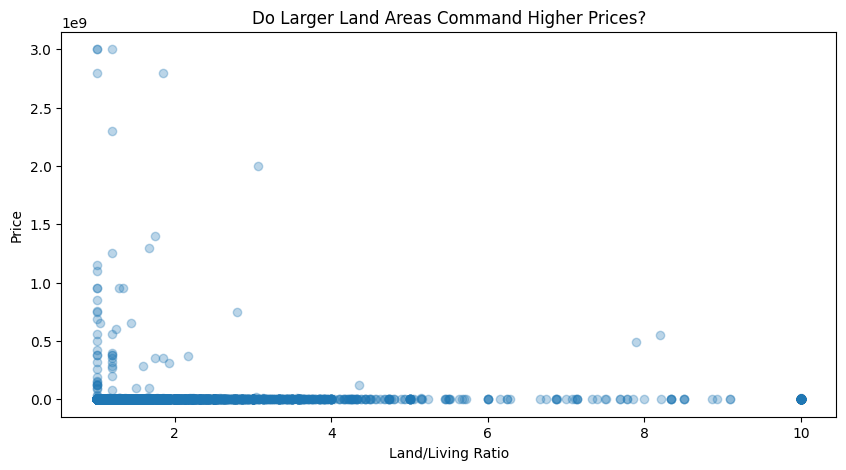

In [382]:
# Plot price vs. ratio for houses
plt.figure(figsize=(10,5))
plt.scatter(df[house_mask]['land_living_ratio'], df[house_mask]['price'], alpha=0.3)
plt.xlabel("Land/Living Ratio")
plt.ylabel("Price")
plt.title("Do Larger Land Areas Command Higher Prices?")
plt.show()

In [383]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9163 entries, 0 to 14348
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               9163 non-null   float64
 1   property_type       9163 non-null   object 
 2   bedrooms            9163 non-null   int64  
 3   bathrooms           9163 non-null   int64  
 4   total_rooms         9163 non-null   float64
 5   living_area         9163 non-null   float64
 6   land_area           9163 non-null   float64
 7   construction_year   2683 non-null   float64
 8   neighborhood        9160 non-null   object 
 9   city                9160 non-null   object 
 10  climatisation       9163 non-null   int64  
 11  parabole_tv         9163 non-null   int64  
 12  pool                9163 non-null   int64  
 13  handicapped_access  9163 non-null   int64  
 14  parking             9163 non-null   int64  
 15  garage              9163 non-null   int64  
 16  garden    

In [384]:
df['construction_year'].describe()

count    2.683000e+03
mean     1.026433e+04
std      4.291728e+05
min      1.000000e+00
25%      2.006000e+03
50%      2.015000e+03
75%      2.020000e+03
max      2.223212e+07
Name: construction_year, dtype: float64

In [385]:
df['construction_year'].isna().mean()

np.float64(0.7071919676961694)

In [386]:
# Step 1: Convert to float first (handles NaNs gracefully)
df['construction_year'] = df['construction_year'].astype(float)

# Step 2: Fill NaNs with a placeholder (e.g., 0 or median)
# Option A: Use median year (better for modeling)
construction_median = df['construction_year'].median()
df['construction_year'] = df['construction_year'].fillna(construction_median)

# Option B: Use 0 + create missingness flag (more transparent)
# df['construction_year_missing'] = df['construction_year'].isna().astype(int)
# df['construction_year'] = df['construction_year'].fillna(0)

# Step 3: Now safely convert to integer
df['construction_year'] = df['construction_year'].astype(int)

# Step 4: Filter impossible years (after conversion)
valid_years = (df['construction_year'] >= 1800) & (df['construction_year'] <= 2025)
df = df[valid_years].copy()

print(f"Final year range: {df['construction_year'].min()} to {df['construction_year'].max()}")

Final year range: 1876 to 2025


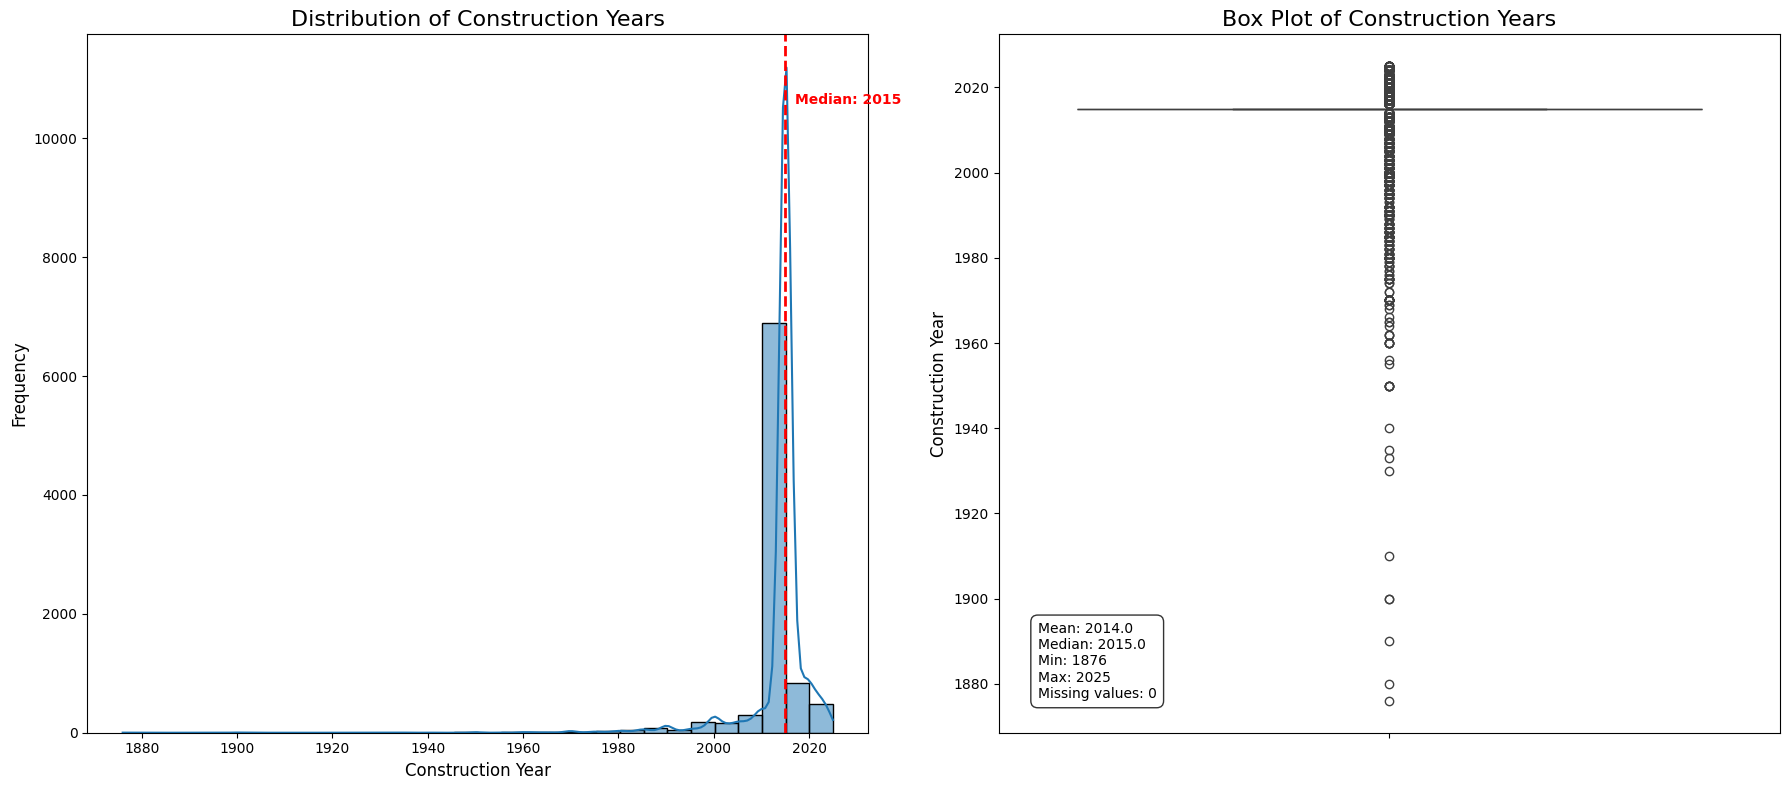


Decade-wise distribution of properties:
1870s: 1 properties (0.0%)
1880s: 1 properties (0.0%)
1890s: 1 properties (0.0%)
1900s: 2 properties (0.0%)
1910s: 1 properties (0.0%)
1930s: 3 properties (0.0%)
1940s: 1 properties (0.0%)
1950s: 7 properties (0.1%)
1960s: 15 properties (0.2%)
1970s: 35 properties (0.4%)
1980s: 76 properties (0.8%)
1990s: 163 properties (1.8%)
2000s: 448 properties (4.9%)
2010s: 7636 properties (83.9%)
2020s: 715 properties (7.9%)


In [387]:
# Create a chart for construction year distribution
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Check if construction year column exists
if 'construction_year' in df.columns:
    year_col = 'construction_year'
elif 'year_built' in df.columns:
    year_col = 'year_built'
else:
    # Try to find the column containing construction year data
    possible_cols = [col for col in df.columns if 'year' in col.lower() or 'built' in col.lower() or 'construct' in col.lower()]
    if possible_cols:
        year_col = possible_cols[0]
        print(f"Using column: {year_col}")
    else:
        raise ValueError("Could not find construction year column. Please specify the correct column name.")

# Convert to numeric and handle any non-numeric values
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 1. Histogram with KDE
sns.histplot(df[year_col].dropna(), kde=True, bins=30, ax=ax1)
ax1.set_title('Distribution of Construction Years', fontsize=16)
ax1.set_xlabel('Construction Year', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)

# Add vertical line for median year
median_year = df[year_col].median()
ax1.axvline(median_year, color='red', linestyle='--', linewidth=2)
ax1.text(median_year+2, ax1.get_ylim()[1]*0.9, f'Median: {median_year:.0f}', 
         color='red', fontweight='bold')

# 2. Box plot to show outliers
sns.boxplot(y=df[year_col].dropna(), ax=ax2)
ax2.set_title('Box Plot of Construction Years', fontsize=16)
ax2.set_ylabel('Construction Year', fontsize=12)

# Add some statistics as text
stats_text = (
    f"Mean: {df[year_col].mean():.1f}\n"
    f"Median: {df[year_col].median():.1f}\n"
    f"Min: {df[year_col].min():.0f}\n"
    f"Max: {df[year_col].max():.0f}\n"
    f"Missing values: {df[year_col].isnull().sum()}"
)
ax2.text(0.05, 0.05, stats_text, transform=ax2.transAxes, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Print decade-wise distribution
print("\nDecade-wise distribution of properties:")
df['decade'] = (df[year_col] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index()
for decade, count in decade_counts.items():
    if not np.isnan(decade):
        percentage = (count / df['decade'].count()) * 100
        print(f"{decade:.0f}s: {count} properties ({percentage:.1f}%)")

In [388]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9105 entries, 0 to 14348
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               9105 non-null   float64
 1   property_type       9105 non-null   object 
 2   bedrooms            9105 non-null   int64  
 3   bathrooms           9105 non-null   int64  
 4   total_rooms         9105 non-null   float64
 5   living_area         9105 non-null   float64
 6   land_area           9105 non-null   float64
 7   construction_year   9105 non-null   int64  
 8   neighborhood        9102 non-null   object 
 9   city                9102 non-null   object 
 10  climatisation       9105 non-null   int64  
 11  parabole_tv         9105 non-null   int64  
 12  pool                9105 non-null   int64  
 13  handicapped_access  9105 non-null   int64  
 14  parking             9105 non-null   int64  
 15  garage              9105 non-null   int64  
 16  garden    

In [389]:
df.shape

(9105, 34)

In [390]:
# 1. Keep raw binary amenities (0/1)
binary_cols = [
    'pool', 'fireplace', 'sea_view', 'elevator', 'alarm_system',
    'garden', 'terrace', 'garage', 'furnished', 'kitchen_equipped'
]

# 2. Add these 3 composite scores
df['luxury_score'] = df[['pool', 'fireplace', 'sea_view', 'elevator']].sum(axis=1)
df['practical_score'] = df[['parking', 'garage', 'kitchen_equipped']].sum(axis=1)
df['outdoor_score'] = df[['garden', 'terrace']].sum(axis=1)

# 3. Add one key interaction (normalized)
df['luxury_x_size'] = df['luxury_score'] * (df['living_area'] / 100)

# Final features to use in ALL models:
final_features = binary_cols + [
    'luxury_score', 
    'practical_score', 
    'outdoor_score',
    'luxury_x_size'
]

In [393]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9105 entries, 0 to 14348
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               9105 non-null   float64
 1   property_type       9105 non-null   object 
 2   bedrooms            9105 non-null   int64  
 3   bathrooms           9105 non-null   int64  
 4   total_rooms         9105 non-null   float64
 5   living_area         9105 non-null   float64
 6   land_area           9105 non-null   float64
 7   construction_year   9105 non-null   int64  
 8   neighborhood        9102 non-null   object 
 9   city                9102 non-null   object 
 10  climatisation       9105 non-null   int64  
 11  parabole_tv         9105 non-null   int64  
 12  pool                9105 non-null   int64  
 13  handicapped_access  9105 non-null   int64  
 14  parking             9105 non-null   int64  
 15  garage              9105 non-null   int64  
 16  garden    

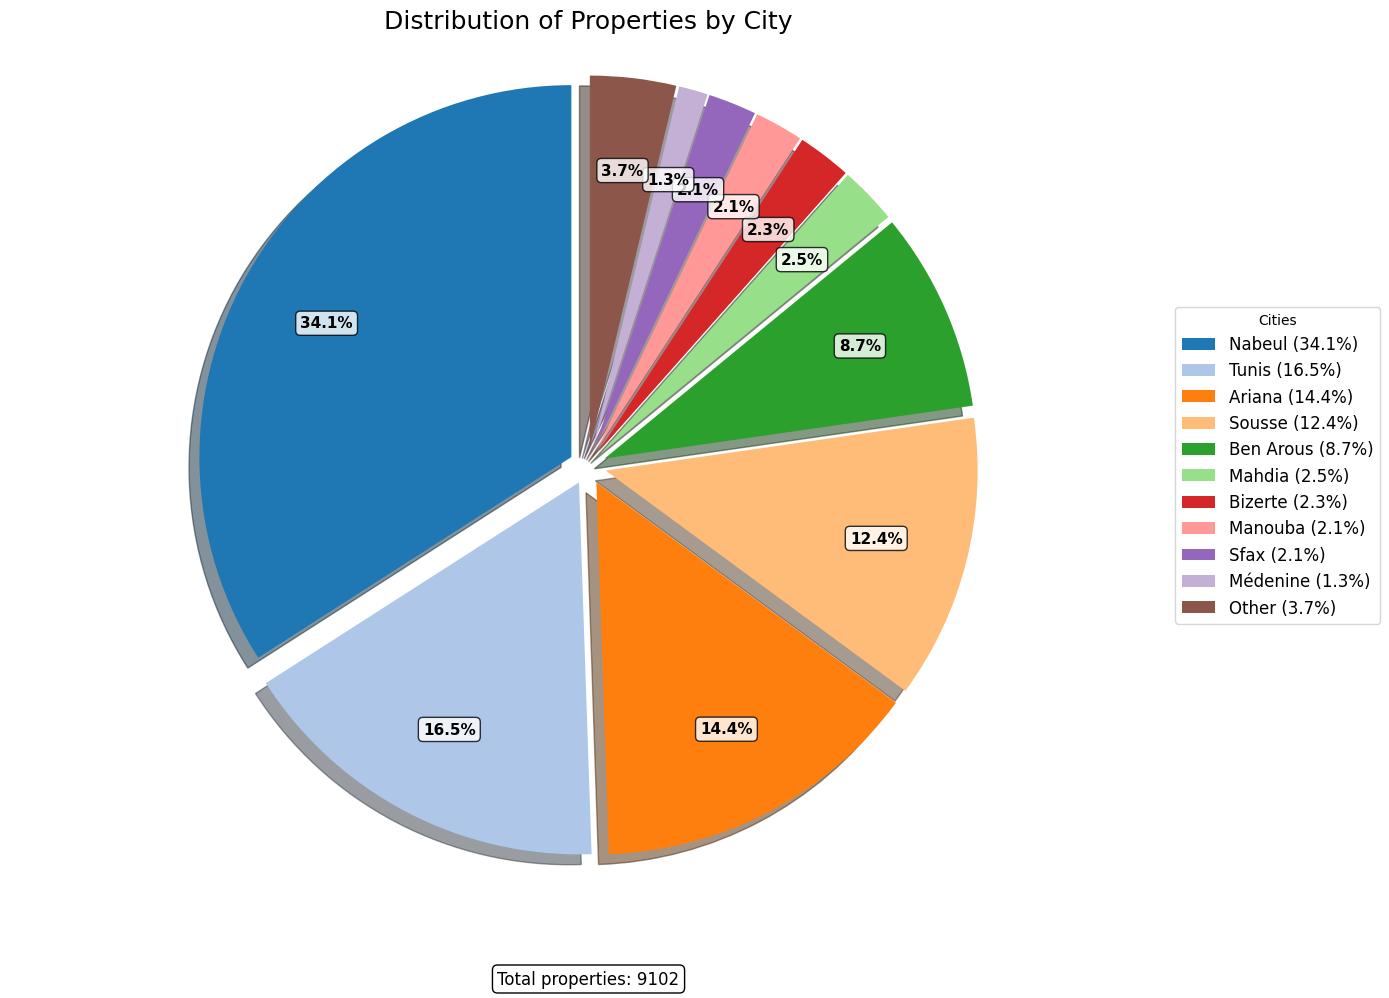

In [391]:
# Create a pie chart for city distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each city
city_counts = df['city'].value_counts()

# If there are too many cities, limit to top 10
if len(city_counts) > 10:
    other_count = city_counts[10:].sum()
    city_counts = city_counts[:10]
    city_counts['Other'] = other_count

# Calculate percentages for better labeling
percentages = (city_counts / city_counts.sum()) * 100
labels = [f'{city} ({pct:.1f}%)' for city, pct in zip(city_counts.index, percentages)]

# Define a color palette with good contrast
colors = plt.cm.tab20(range(len(city_counts)))

# Create a pie chart with enhanced visibility
plt.figure(figsize=(14, 10))

# Create the pie chart with percentage labels
wedges, texts, autotexts = plt.pie(city_counts, labels=None, 
                       autopct='%1.1f%%',
                       startangle=90, shadow=True, 
                       explode=[0.05]*len(city_counts),
                       colors=colors,
                       pctdistance=0.75)  # Position the percentages

# Enhance the appearance of percentage text on the pie
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')
    autotext.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

plt.title('Distribution of Properties by City', fontsize=18)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Add a legend with percentages included in the labels
plt.legend(wedges, labels, title="Cities", 
          loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

# Add a text box with the total count
plt.annotate(f'Total properties: {city_counts.sum()}', 
            xy=(0.5, -0.1), xycoords='axes fraction',
            ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

plt.tight_layout()
plt.show()